## Intelligent Customer Service System

This notebook walks through the development of a customer service system that can:
- categorize customer inquiries automatically
- detect customer sentiment
- extract important information such as customer names, product names, and issues
- retrieve relevant company knowledge
- generste appropriate responses automatically
- escalate critical cases to human agents

#### System Architecture
The process is as below: 
Customer query -> preprocessing -> NER + Sentiment Analysis + Query Classification
-> Knowledge Retrieval (RAG) -> LLM Response Generation -> Escalation Decision -> Final Response

#### Four Basic NLP Techniques Utilized
- Text Preprocessing Pipeline<br/>
  Purpose: Clean and normalize customer messages<br/>
  Methods: Lowercasing, Tokenization, Stop-word removal, Lemmatization
- Named Entity Recognition (NER)<br/>
  Purpose: Extract customer names, product names, organizations<br/>
  Tools: spaCy
- Traditional Text Classification (TF-IDF + Logistic Regression)<br/>
  Purpose: Categorize customer requests
- Sentiment Analysis<br/>
  Purpose: Determine customer emotion<br/>
  Classes: Positive, Negative, Neutral<br/>
  Model: TF-IDF + Naive Bayes

#### Five Advanced NLP Techniques Utilized
- LLM-based Response Generation<br/>
  Purpose: Generate human-like responses
- Retrieval-Augmented Generation (RAG)<br/>
  Purpose: Prevent hallucinations
- Prompt Engineering<br/>
  Purpose: Improve response quality
- Agentic Design<br/>
  Purpose: Create specialized agents
- Automated Escalation using LLM Classification<br/>
  Purpose: Detect urgent situations

In [6]:
# check if the necessary packages exist
!pip show nltk spacy sentence-transformers

Name: nltk
Version: 3.9.4
Summary: Natural Language Toolkit
Home-page: https://www.nltk.org/
Author: NLTK Team
Author-email: nltk.team@gmail.com
License: Apache License, Version 2.0
Location: E:\comp8420a3\venv\Lib\site-packages
Requires: click, joblib, regex, tqdm
Required-by: 
---
Name: spacy
Version: 3.8.14
Summary: Industrial-strength Natural Language Processing (NLP) in Python
Home-page: https://spacy.io
Author: Explosion
Author-email: contact@explosion.ai
License: MIT
Location: E:\comp8420a3\venv\Lib\site-packages
Requires: catalogue, confection, cymem, jinja2, murmurhash, numpy, packaging, preshed, pydantic, requests, setuptools, spacy-legacy, spacy-loggers, srsly, thinc, tqdm, typer, wasabi, weasel
Required-by: 
---
Name: sentence-transformers
Version: 5.5.1
Summary: Embeddings, Retrieval, and Reranking
Home-page: https://www.SBERT.net
Author: 
Author-email: Nils Reimers <info@nils-reimers.de>, Tom Aarsen <tom.aarsen@huggingface.co>
License: Apache 2.0
Location: E:\comp8420a3\v

In [3]:
# nltk
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# we will use vader for sentiment analysis
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 2.2 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 2.6 MB/s eta 0:00:05
     ------ --------------------------------- 2.1/12.8 MB 2.8 MB/s eta 0:00:04
     -------- ------------------------------- 2.6/12.8 MB 2.6 MB/s eta 0:00:04
     --------- ------------------------------ 3.1/12.8 MB 2.6 MB/s eta 0:00:04
     ----------- ---------------------------- 3.7/12.8 MB 2.7 MB/s eta 0:00:04
     ------------- -------------------------- 4.2/12.8 MB 2.6 MB/s eta 0:00:04
     -------------- ------------------------- 4.7/12.8 MB 2.6 MB/s eta 0:00:04
     ----------------- ---------------------- 5.5/12.8 MB 2.8 MB/s eta 0:00:03
     ------------------- -------------------- 6.3/12.8 MB 2.8 MB/s eta 0:

In [76]:
# import necessary libraries
import os
from dotenv import load_dotenv
import pandas as pd

# import visualization tools
import seaborn as sns
import matplotlib.pyplot as plt

# import nlp tools
import re
import spacy

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

In [80]:
# load env variables to expose gemini api key
load_dotenv()

True

In [79]:
# constants
REQUIRED_COLS = [
    'tweet_id', 'author_id', 'inbound', 'created_at',
    'text', 'response_tweet_id', 'in_response_to_tweet_id'
]

COMPLAINT_KW = [
    'not working', 'broken', 'error', 'issue', 'problem', 'fail', 'failed',
    'terrible', 'awful', 'horrible', 'worst', 'disappointed', 'frustrated',
    'useless', 'wrong', 'bad', 'hate', 'ridiculous', 'unacceptable',
    'outraged', 'fix this', 'still not', 'never works', 'pathetic'
]

POSITIVE_KW = [
    'thank', 'thanks', 'great job', 'love this', 'awesome', 'excellent',
    'amazing', 'wonderful', 'fantastic', 'good job', 'well done',
    'appreciate', 'perfect'
]

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

## Dataset 
We used the Customer Support on Twitter dataset. It contains:
- customer messages
- company replies
- multiple support categories
- real-world customer complaints
- data suitable for sentiment analysis and response generation

In [11]:
# load dataset
df = pd.read_csv('dataset/twcs.csv')

# display first 5 rows
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [12]:
# check dataset shape 
df.shape

(2811774, 7)

In [13]:
# show columns
print(f'\nColumns: {df.columns.tolist()}')

print('=======================================')

# show data type of each column
print(f'\nDtypes:\n{df.dtypes}')

print('=======================================')

# check dataset shape
print('Dataset shape:', df.shape)

print('=======================================')

# check missing values
print('Missing values per column')
print(df.isnull().sum())


Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Dtypes:
tweet_id                     int64
author_id                      str
inbound                       bool
created_at                     str
text                           str
response_tweet_id              str
in_response_to_tweet_id    float64
dtype: object
Dataset shape: (2811774, 7)
Missing values per column
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64


## Dataset Exploration

In [14]:
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(f'Missing expected columns: {missing}')

print('All required columns present.')
print(f'\nNull counts:\n{df[REQUIRED_COLS].isnull().sum()}')

All required columns present.

Null counts:
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64


In [15]:
# normalize inbound flag
df['inbound'] = (
    df['inbound'].astype(str).str.strip()
    .map({'True': True, 'False': False, '1': True, '0': False})
)
df = df.dropna(subset=['inbound'])
df['inbound'] = df['inbound'].astype(bool)

# show customer responses
print(f'Inbound (customer) tweets : {df["inbound"].sum():,}')
# show company responses
print(f'Outbound (company) tweets : {(~df["inbound"]).sum():,}')

Inbound (customer) tweets : 1,537,843
Outbound (company) tweets : 1,273,931


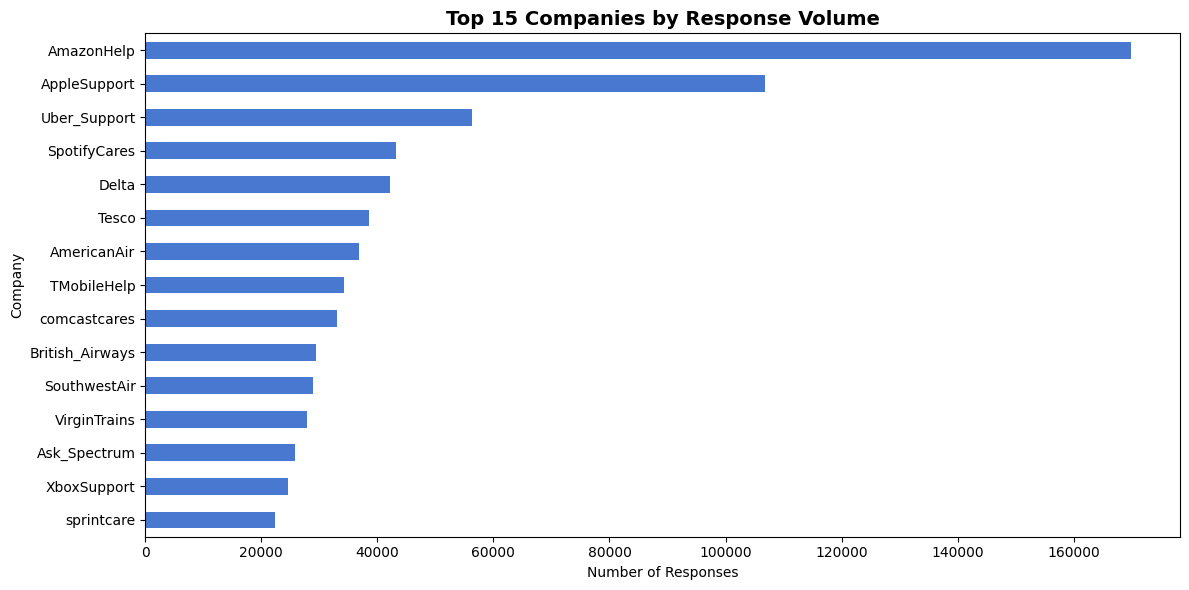

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381


In [16]:
# show total responses by different companies in the dataset
outbound = df[~df['inbound']].copy()
top_companies = outbound['author_id'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_companies.plot(kind='barh', ax=ax, color=sns.color_palette('muted')[0])
ax.set_title('Top 15 Companies by Response Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Responses')
ax.set_ylabel('Company')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(top_companies.to_string())

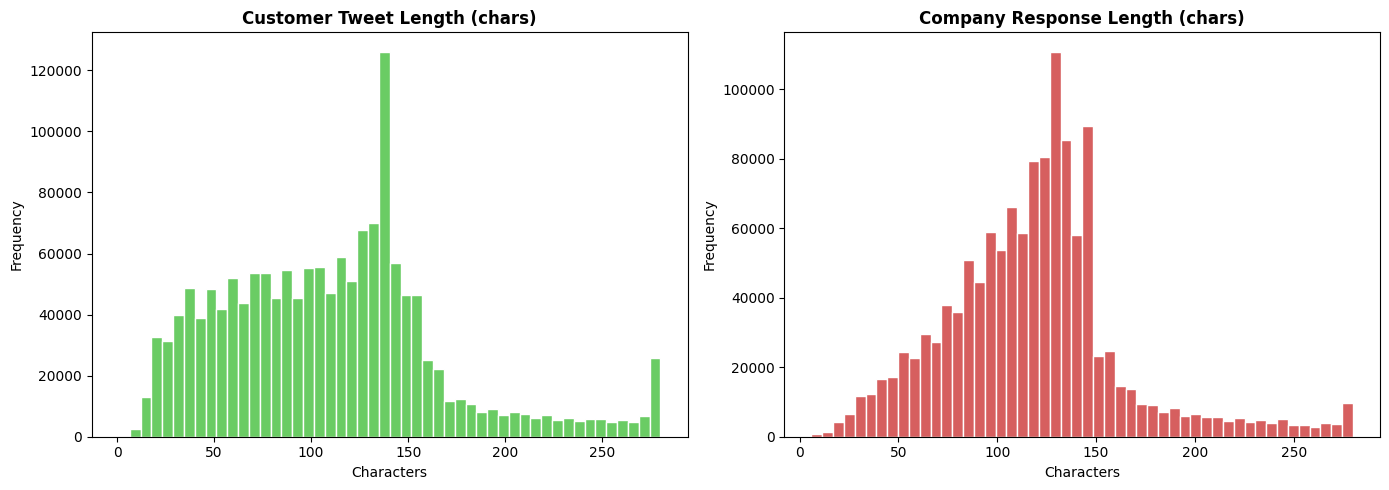

In [17]:
df['text_length'] = df['text'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('muted')

df[df['inbound']]['text_length'].clip(upper=280).plot(
    kind='hist', bins=50, ax=axes[0],
    color=colors[2], edgecolor='white'
)
axes[0].set_title('Customer Tweet Length (chars)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Characters')

df[~df['inbound']]['text_length'].clip(upper=280).plot(
    kind='hist', bins=50, ax=axes[1],
    color=colors[3], edgecolor='white'
)
axes[1].set_title('Company Response Length (chars)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

In [18]:
# function to label intent
def label_intent(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 'other'
    t = text.lower()
    if any(kw in t for kw in COMPLAINT_KW):
        return 'complaint'
    if '?' in text:
        return 'question'
    if any(kw in t for kw in POSITIVE_KW):
        return 'positive'
    return 'other'

In [19]:
df['intent'] = df['text'].apply(label_intent)

intent_counts = df['intent'].value_counts()
intent_pct = df['intent'].value_counts(normalize=True).mul(100).round(1)

intent_summary = pd.DataFrame({'count': intent_counts, 'pct': intent_pct})
print(intent_summary.to_string())

             count   pct
intent                  
other      1559381  55.5
question    605448  21.5
complaint   362772  12.9
positive    284173  10.1


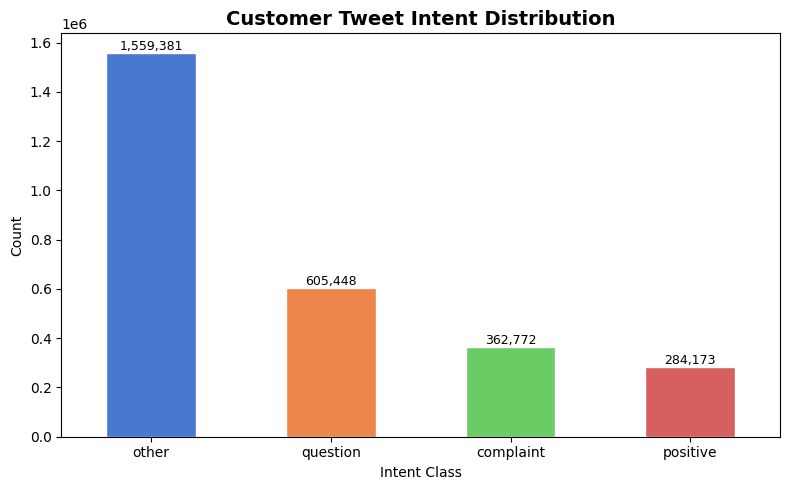

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
intent_counts.plot(
    kind='bar', ax=ax,
    color=sns.color_palette('muted')[:4],
    edgecolor='white'
)
ax.set_title('Customer Tweet Intent Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Phase 1: Data Cleaning & Preprocessing (Basic NLP-1)

In [21]:
# initialize objects
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [22]:
# function to clean text
def preprocess_text(text):
    # step 1: convert to lowercase
    text = text.lower()

    # step 2: remove URLs if present
    text = re.sub(r'http\S+', '', text)

    # step 3: remove mentions
    text = re.sub(r'@\w+', '', text)

    # step 4: remove special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)

    # step 5: tokenization
    tokens = word_tokenize(text)

    # step 6: remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # step 7: lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [23]:
# apply preprocessing to generate cleaned text column
df['clean_text'] = df['text'].astype(str).apply(preprocess_text)

df[['text','clean_text']].head()

,text,clean_text
0,@115712 I understand. I would like to assist y...,understand would like assist would need get pr...
1,@sprintcare and how do you propose we do that,propose
2,@sprintcare I have sent several private messag...,sent several private message one responding usual
3,@115712 Please send us a Private Message so th...,please send u private message assist click mes...
4,@sprintcare I did.,


In [57]:
# function to assign custom categories
def assign_category(text):
    text = text.lower()

    categories = {
        "Returns & Refunds": [
            "refund", "return", "money back", "exchange",
            "damaged item", "wrong item", "replacement"
        ],

        "Delivery & Shipping": [
            "delivery", "shipping", "ship", "track",
            "tracking", "arrival", "dispatch", "courier"
        ],

        "Orders": [
            "order", "purchase", "checkout",
            "basket", "cart", "buy"
        ],

        "Payments & Billing": [
            "payment", "billing", "invoice",
            "charge", "charged", "credit card",
            "debit card", "wallet", "gift card"
        ],

        "Account & Login": [
            "account", "login", "log in", "sign in",
            "password", "username", "reset password"
        ],

        "Loyalty Program": [
            "loyalty", "reward", "points",
            "membership", "member", "discount points"
        ],

        "Products & Availability": [
            "product", "stock", "availability",
            "available", "out of stock", "inventory",
            "allergen", "organic", "vegan", "halal",
            "gluten free"
        ],

        "Store Information": [
            "store", "opening hours", "closing",
            "location", "address", "branch"
        ],

        "Promotions & Discounts": [
            "promotion", "discount", "coupon",
            "sale", "special offer", "deal"
        ]
    }

    for category, keywords in categories.items():
        if any(keyword in text for keyword in keywords):
            return category

    return "General Inquiry"

In [58]:
df['category'] = df['text'].astype(str).apply(assign_category)
print(df['category'].value_counts())

category
General Inquiry            2114648
Orders                      125229
Account & Login             124061
Store Information           110447
Delivery & Shipping          98827
Returns & Refunds            67404
Products & Availability      61797
Payments & Billing           56984
Promotions & Discounts       27573
Loyalty Program              24804
Name: count, dtype: int64


## Phase 2: Query Classification (Basic NLP-2)

In [26]:
# feature extraction
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['clean_text'])

y = df['category']

In [27]:
# split into train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# train logistic regression
classifier = LogisticRegression()

classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [30]:
# evaluate the classifier
predictions = classifier.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

     Account       0.99      0.95      0.97      2268
     Billing       0.99      0.96      0.98      2780
Cancellation       0.99      0.96      0.97      7793
     General       1.00      1.00      1.00    541967
      Refund       1.00      0.96      0.98      7547

    accuracy                           1.00    562355
   macro avg       1.00      0.97      0.98    562355
weighted avg       1.00      1.00      1.00    562355



## Phase 3: Named Entity Recognition (Basic NLP-3)

In [32]:
# load spaCy
nlp = spacy.load("en_core_web_sm")

In [33]:
# function to extract entities
def extract_entities(text):
    doc = nlp(text)
    entities = []

    for ent in doc.ents:
        entities.append(
            (ent.text, ent.label_)
        )

    return entities

In [34]:
# sample entity testing
print(extract_entities("My Microsoft Surface Pro stopped working."))

[('Microsoft Surface Pro', 'ORG')]


In [35]:
# pos tagging
def pos_tags(text):
    doc = nlp(text)
    tags = []

    for token in doc:
        tags.append((token.text, token.pos_))

    return tags

In [36]:
# sample pos tagging
print(pos_tags("My laptop stopped working yesterday"))

[('My', 'PRON'), ('laptop', 'NOUN'), ('stopped', 'VERB'), ('working', 'VERB'), ('yesterday', 'NOUN')]


## Phase 4: Sentiment Analysis (Basic NLP-4)

In [37]:
# initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [59]:
# frustration indicators
frustration_words = [
    "unacceptable", "terrible", "awful", "angry",
    "frustrated", "disappointed", "complaint",
    "refund immediately", "cancel my order",
    "worst", "ridiculous"
]

# urgency indicators
urgency_words = [
    "urgent", "asap", "immediately",
    "right now", "still waiting"
]

In [60]:
# sentiment extractor function
def get_sentiment(text):
    score = sia.polarity_scores(text)
    compound = score['compound']

    text_lower = text.lower()

    frustration_score = sum(
        1 for word in frustration_words if word in text_lower
    )

    urgency_score = sum(
        1 for word in urgency_words if word in text_lower
    )

    exclamation_count = text.count("!")

    # Strong negative escalation
    if compound <= -0.5 or frustration_score >= 2:
        return "Very Negative"

    # Negative
    elif compound <= -0.1:
        return "Negative"

    # Strong positive
    elif compound >= 0.6:
        return "Very Positive"

    # Positive
    elif compound >= 0.1:
        return "Positive"

    # Neutral but urgent
    elif urgency_score > 0 or exclamation_count >= 3:
        return "Urgent"

    return "Neutral"

In [61]:
df['sentiment'] = df['text'].astype(str).apply(get_sentiment)

print(df['sentiment'].value_counts())

sentiment
Positive         819051
Neutral          794846
Very Positive    561787
Negative         380992
Very Negative    239301
Urgent            15797
Name: count, dtype: int64


## Phase 5: Retrieval Augmented Generation (Advanced NLP-1)

In [46]:
# knowledge base for RAG
knowledge_base = [
    # Store Information
    "Our stores are open from 7:00 AM to 10:00 PM, seven days a week.",
    "Customers can check product availability online or through the mobile app.",
    "Store locations and opening hours are available on the company website.",

    # Orders & Delivery
    "Standard home delivery typically arrives within 1-3 business days.",
    "Same-day delivery is available for orders placed before 12:00 PM in eligible areas.",
    "Customers receive tracking updates via email and SMS after an order is dispatched.",
    "Delivery fees vary based on location and order value.",

    # Returns & Refunds
    "Customers can return most unopened products within 30 days of purchase with a valid receipt.",
    "Perishable items such as fresh produce, meat, and dairy may be refunded if quality issues are reported within 48 hours of purchase.",
    "Refunds are processed to the original payment method within 5-10 business days.",

    # Loyalty Program
    "Members earn loyalty points on eligible purchases.",
    "Accumulated points can be redeemed for discounts on future purchases.",
    "Exclusive member-only promotions are available through the loyalty program.",

    # Payments
    "We accept major credit cards, debit cards, digital wallets, and gift cards.",
    "Online orders must be paid before dispatch.",
    "Gift cards can be used both online and in-store.",

    # Product Information
    "Nutritional information and allergen details are available on product packaging and online.",
    "Organic, gluten-free, vegan, and halal products are clearly labeled.",
    "Product availability may vary by store location.",

    # Customer Support
    "Premium members receive priority customer support.",
    "Customer support is available via phone, email, and live chat.",
    "Damaged or incorrect orders should be reported within 24 hours of delivery.",

    # Promotions
    "Weekly specials are updated every Wednesday.",
    "Promotional offers cannot usually be combined unless stated otherwise.",
    "Rain checks may be offered for selected out-of-stock promotional items."
]

In [42]:
# sentence embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

E:\comp8420a3\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [47]:
# encode knowledge base
kb_embeddings = model.encode(knowledge_base)

In [50]:
# similarity search
def retrieve_context(query):
    query_embedding = model.encode([query])

    # find similarity
    similarities = cosine_similarity(query_embedding, kb_embeddings)

    index = similarities.argmax()

    return knowledge_base[index]

In [51]:
# sample similarity search
print(retrieve_context("How do I get my refund?"))

Refunds are processed to the original payment method within 5-10 business days.


## Phase 6: Prompt Engineering (Advanced NLP-2)

In [66]:
# function to generate prompt based on customer query, sentiment and context
def create_prompt(query, category, sentiment, context):
    prompt = f"""
    You are a professional and empathetic customer support assistant.
    Customer Information:
    Category: {category}
    Sentiment: {sentiment}
    
    Relevant Knowledge Base: 
    {context}
    
    Customer Message: {query}
    Instructions:
    1. Understand the customer's intent and underlying concern.
    2. Use the provided knowledge base information whenever relevant.
    3. Adapt your tone based on customer sentiment:
       - Negative: acknowledge concerns, remain calm and provide clear step-by-step guidance.
       - Positive: maintain a friendly and positive tone.
       - Neutral: provide concise and professional assistance.
    4. Be accurate and avoid making up information not found in the knowledge base.
    5. If the knowledge base does not contain enough information, clearly state that additional information may be required.
    6. Provide actionable next steps whenever possible.
    7. Keep the response professional, concise, and customer-focused.

Generate a complete customer support response.
    """
    return prompt

## Phase 7: LLM Response Generation (Advanced NLP-3)

In [81]:
from google import genai

# read the api key from env
client = genai.Client(
    api_key=GEMINI_API_KEY
)

In [72]:
# function to generate llm response
def generate_response(prompt):
    response = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt
    )

    return response.text

## Phase 8: Automated Escalation Agent (Advanced NLP-4)

In [62]:
escalation_keywords = {
    "Legal Threat": [
        "lawyer", "attorney", "legal action",
        "lawsuit", "sue", "court"
    ],

    "Manager Request": [
        "manager", "supervisor",
        "human agent", "representative"
    ],

    "Formal Complaint": [
        "complaint", "ombudsman",
        "consumer affairs", "report"
    ],

    "Severe Frustration": [
        "unacceptable", "ridiculous",
        "terrible service", "worst experience",
        "extremely disappointed"
    ],

    "Security Issue": [
        "fraud", "unauthorized",
        "hacked", "stolen card",
        "security breach"
    ]
}

In [63]:
def escalation_check(sentiment, text):
    text = text.lower()

    for reason, keywords in escalation_keywords.items():
        if any(keyword in text for keyword in keywords):
            return {
                "escalate": True,
                "priority": "High",
                "reason": reason
            }

    if sentiment in ["Very Negative", "Negative"]:
        return {
            "escalate": True,
            "priority": "Medium",
            "reason": "Negative customer sentiment"
        }

    return {
        "escalate": False,
        "priority": "Low",
        "reason": None
    }

## Phase 9: Agentic Workflow (Advanced NLP-5)

In [64]:
def customer_service_agent(query):
    # assign category to the customer query
    category = assign_category(query)
    # extract sentiment
    sentiment = get_sentiment(query)
    # extract entities from the query
    entities = extract_entities(query)
    # extract context based on the knowledge base
    context = retrieve_context(query)

    # generate prompt
    prompt = create_prompt(query, category, sentiment, context)

    # generate response
    response = generate_response(prompt)

    escalation = escalation_check(sentiment, query)

    return {
        "category": category,
        "sentiment": sentiment,
        "entities": entities,
        "retrieved_context": context,
        "response": response,
        "escalation": escalation
    }

In [82]:
# sample run
query = """
I requested a refund last week
and nobody replied yet. It's very frustrating
"""

result = customer_service_agent(query)

print(result)

{'category': 'Returns & Refunds', 'sentiment': 'Negative', 'entities': [('last week', 'DATE')], 'retrieved_context': 'Refunds are processed to the original payment method within 5-10 business days.', 'response': 'Hello,\n\nThank you for reaching out. I sincerely apologize for the delay in our response and the frustration this has caused you. I understand how important it is to receive timely updates regarding your money.\n\nTo help me look into this for you, please provide your **order number**. \n\nIn the meantime, here is some general information regarding our process:\n*   Once a refund is processed, it is issued back to your **original payment method**.\n*   It typically takes **5-10 business days** for the funds to appear in your account, depending on your financial institution.\n\nSince you mentioned you have not yet received a reply to your initial request, I will prioritize investigating your case as soon as you provide your order details. I will then be able to confirm if the 